# This notebook shows you how to generate your own DBOF


In [1]:
import datetime

# Initial set up

## These steps help you build the project on a local machine. 
If you are using nrp Jupyterhub, it is recommended you use the next block instead.

#### Build the project
- ```pip install .```
or if running in a conda environment
- ```pip install . --no-deps```

#### Install aws cli (optional)
You will want to install this if you want to manually see the data stored in the s3 bucket.

Example for installing on linux :
- ```sudo curl "https://awscli.amazonaws.com/awscli-exe-linux-x86_64.zip" -o "awscliv2.zip"```
- ```sudo unzip awscliv2.zip```
- ```sudo ./aws/install```

## Set AWS credentials
If you are accessing or writing data to S3, you must set credentials.
NOTE : S3 is all that is supported currently.
This typically corresponds to an NRP S3 bucket.

windows:

- ```$env:AWS_ACCESS_KEY_ID="..."```
- ```$env:AWS_SECRET_ACCESS_KEY="..."```

unix:

- ```export AWS_ACCESS_KEY_ID=...```
- ```export AWS_SECRET_ACCESS_KEY=...```

# Cutout dataset generation config

This job is controlled by a YAML config with the following properties. You are responsible for creating a yaml for each run you wish to do. However, you can override run id and use the same YAML for different runs.

### Input source (what data is read)
- `input.folder`
  Path (under `input.bucket`) to the generate-global output directory that holds
  the `date_prefix` snapshot folders.
- `input.bucket`, `input.s3_endpoint`
  S3 location of that input.
- `input.date_prefixes`
  Explicit list of snapshot timestamps to process, format `YYYYMMDD_HHMMSS`.
  Omit / leave empty to process **every** date_prefix found under `input.folder`.
  These dates must have been generated already by generate_global.
- `input.grid_access` (`bucket`, `folder`, `dataset_name`, `s3_endpoint`)
  The rectangular LLC4320 grid store. Supplies grid metrics (`dxC`/`dyC`), the
  land mask, and the `XC`/`YC` (lon/lat) coordinates.

### Spatial sampling
- `sampling.sample_points_per_snapshot`
  Number of cutout centers sampled per snapshot.
  Total cutouts generated = samples per snapshot * len of dates
- `sampling.bias_to_high_gradients`
  Bias toward high-gradient regions. Sampling weight ∝ `exp(bias · (log10(gradb2) − min))`,
  so higher values concentrate cutouts on high gradb2 values.

### Feature channels
- `feature_channels` (top-level list)
  The fields written as image channels, **in this order**.
  - Must include `gradb2` (drives sampling) and `SIarea` (builds the ice mask) —
    the config loader errors otherwise.
  - Every name must exist in the global subsets for the snapshot, or the run fails
    fast naming the missing channel. See subset_definitions.py for the exact names.
  - `XC` and `YC` (longitude/latitude) are appended automatically as the final two
    channels — you don't list them.
  - The exact channel order is stored in the dataset (`channel_names` attr) so
    readers don't hardcode it. Written order matches the config order

### Cutout geometry
- `output.target_km_res`
  Physical cutout size in km. Default 150.
- `output.down_sample_res`
  Pixel resolution of each extracted cutout. Default 64. Must be small enough that
  downsampling never upsamples `target_km_res` on the LLC grid. (Coordinate channels
  `XC`/`YC` are downsampled nearest-neighbor; feature channels use area averaging.)

### Output / logging
- `output.bucket`, `output.folder`, `output.dataset_name`
  S3 location + zarr store name for the dataset. Metadata parquet is written
  alongside under `.../metadata/`.
- `run.run_id`
  Identifier used in the output path (`.../folder/run_id/...`). If it already exists
  at the write location, new cutouts are **appended** to the existing store.
- `run.log_dir`
  Local directory where logs are written.

### Runtime
- `runtime.zarr_async_concurrency`
  Concurrency for zarr writes.
- `runtime.dask_*` (`dask_scheduler`, `dask_n_workers`, `dask_threads_per_worker`,
  `dask_memory_limit`)
  Dask execution knobs (optional).

### Invariants (not configurable)
Grid topology and LLC4320 constants are fixed in code. The rectangular grid and the
global snapshots are produced by the upstream generate-global job; this job only
consumes them.

### Examples
- `configs/cutouts/run/run_from_globals_example.yaml` — a full run config.
- `configs/cutouts/data_access/` — data-access configs for reading a generated dataset back.

# A note about logs
The run logs will be stored locally on your machine in the directory you specify.
- ```log_dir/run_id/```
However under the current logic, if you attempt to run the script and the specified log output path already exists, the script will fail to run. This is by design. The reasons are as follows.
- run_id is also used for the zarr dataset path. You likely do not want to send two different runs to the same dataset.
- You will likely not want to override your previous run logs.

If you want to override this logic, simply delete the existing log output path from your local machine. You can also override the run_id with a cli argument ```--run_id```

## Example run 1

In [7]:
run_id = f"2_times_tests_{datetime.datetime.now(datetime.UTC).strftime('%Y%m%d_%H%M%S')}"
print(f"Your run id is: {run_id}")
print("Make sure and use the same run_id later when accessing your data")

Your run id is: 2_times_tests_20260630_223447
Make sure and use the same run_d later when accessing your data


In [8]:
# note: that --run_id can overwrite the config file
# note: All Dask logs are warnings. Don't be alarmed.
!generate-llc-dataset --config ../../configs/cutouts/run/run_from_globals_example.yaml  --run_id {run_id}

JobConfig(run=RunConfig(run_id='cutout_test_data_v1', log_dir='../test_logs/'), input=InputConfig(folder='test_data_for_cutouts/cutout_test_data_v1', s3_endpoint='https://s3-west.nrp-nautilus.io', bucket='dbof', date_prefixes=['20120209_120000', '20120801_120000'], grid_access=GridAccessConfig(s3_endpoint='https://s3-west.nrp-nautilus.io', bucket='dbof', folder='native_grid_dbof_training_data', dataset_name='llc4320_grid.zarr')), sampling=SamplingConfig(bias_to_high_gradients=1.3, sample_points_per_snapshot=150), output=OutputConfig(s3_endpoint='https://s3-west.nrp-nautilus.io', bucket='dbof/', folder='cutouts_dataset_v2_TESTING/', dataset_name='cutout_dataset_creation.zarr', target_km_res=150, down_sample_res=64), features=FeaturesConfig(feature_channels=['Eta', 'Salt', 'Theta', 'U', 'V', 'W', 'gradb2', 'SIarea']), runtime=RuntimeConfig(zarr_async_concurrency=128, dask_scheduler='distributed', dask_n_workers=None, dask_threads_per_worker=None, dask_memory_limit=None))
2026-06-30 15:35

# Access
Use load_cutout_dataset to access the data of your run. The parameters in the access YAML must match the run parameters exactly. See cutout_test_data_v1.yaml for an example. Note that you can override run_id to reuse a YAML.

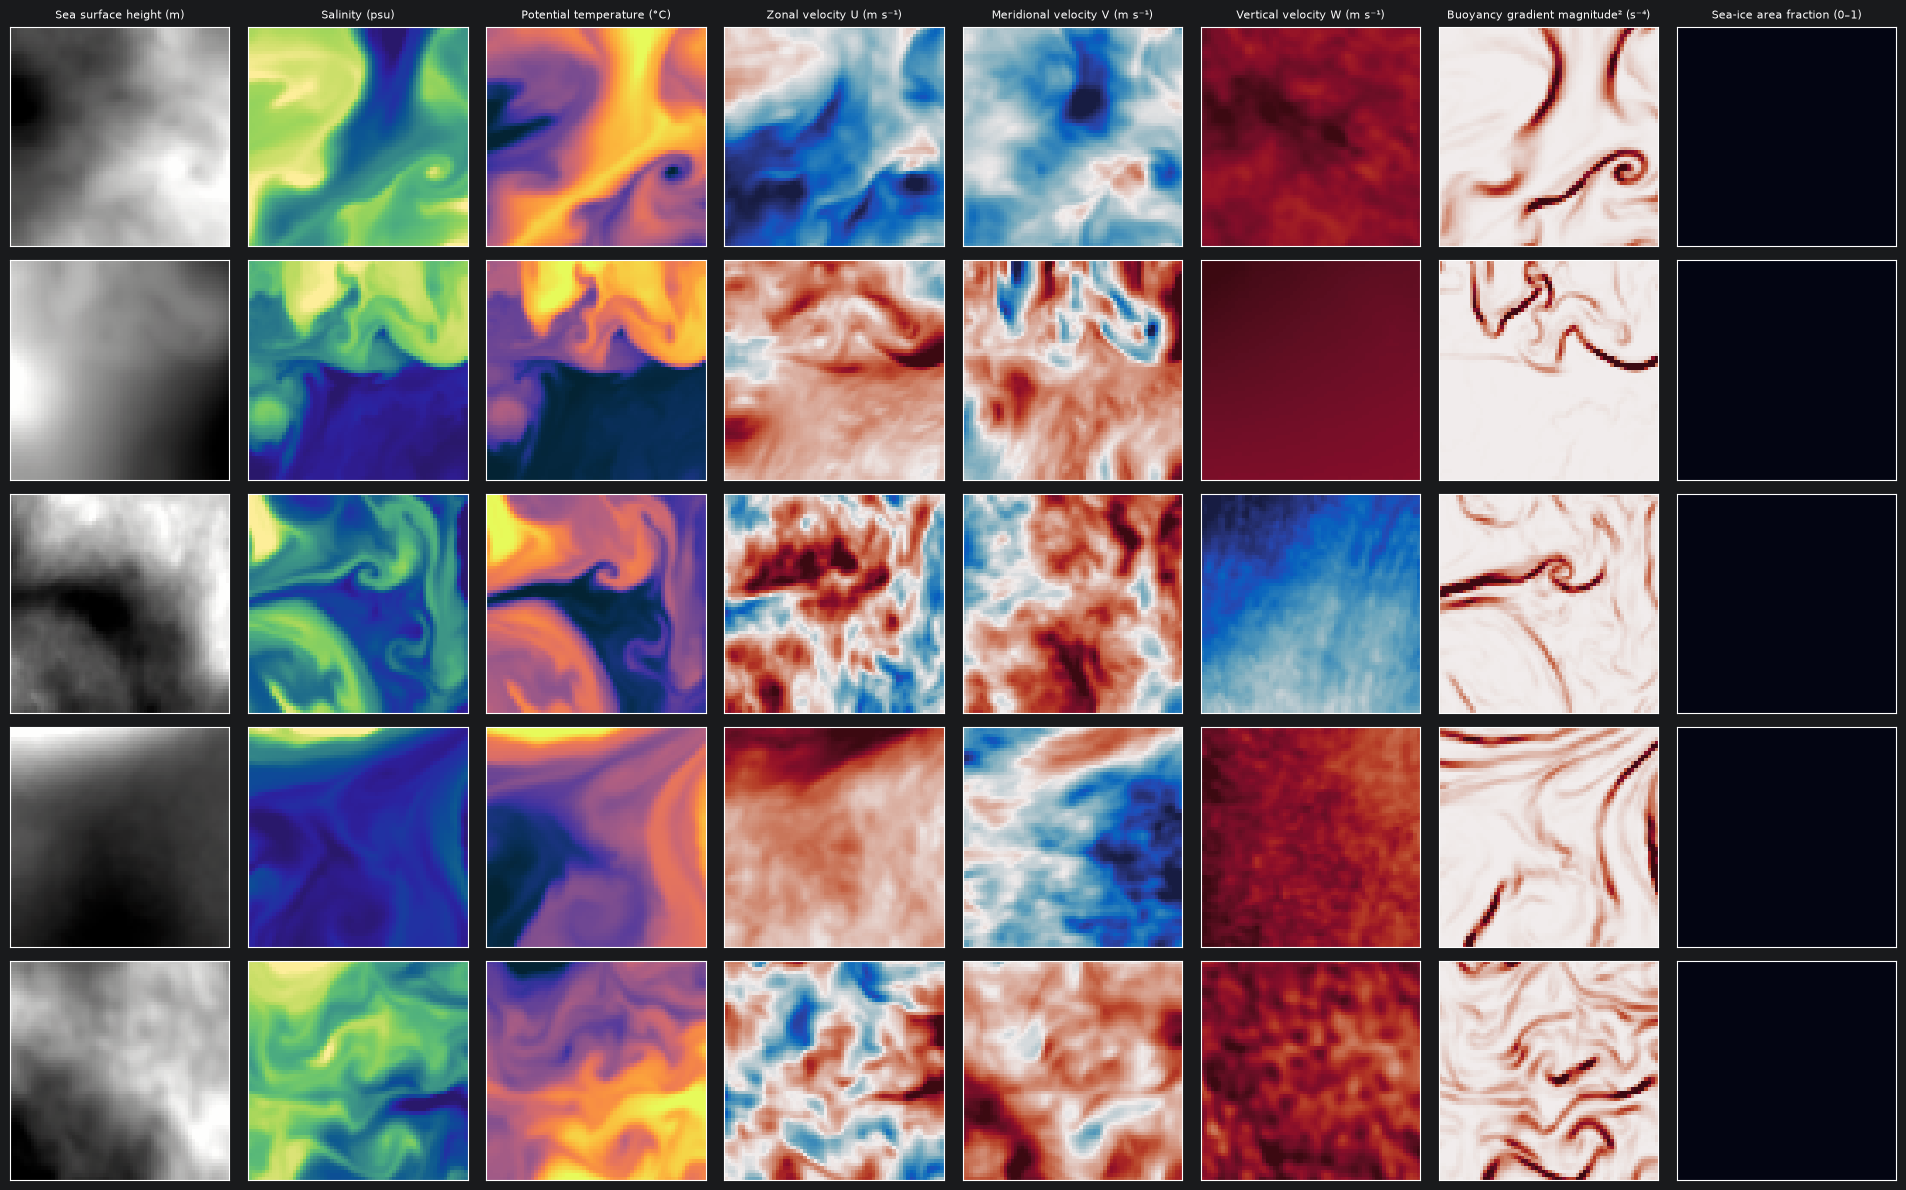

,image_id,native_grid,center_grid_j,center_grid_i,center_lat,center_lon,target_km_res,real_km_w,real_km_h,pre_interp_res,log_grad_b_2_center,time_snapshot
0,e2aadd80f6a14e98a66973631838d87e,LLC4320,7217,119,-13.411017,-35.510418,150,148.700481,149.435838,"[73, 67]",-15.058133,2012-08-01 12:00:00
1,8f7794dfe384474f88ff819fd318ea30,LLC4320,5319,10236,-44.648354,175.260422,150,147.459809,148.303435,"[91, 97]",-13.590013,2012-08-01 12:00:00
2,51013090565d481f9a338c0d029b5c30,LLC4320,5157,9417,-46.847317,158.197922,150,148.255225,148.910273,"[95, 101]",-15.521382,2012-02-09 12:00:00
3,2692ec94463d4b1493eb4e57cbfc4112,LLC4320,5436,4291,-43.011658,51.406250,150,149.040149,147.999065,"[95, 89]",-13.761175,2012-02-09 12:00:00
4,5fbd4c0ea281482db520b9bc639f6be3,LLC4320,9066,10528,21.521133,-178.656250,150,146.570252,146.518488,"[69, 75]",-13.998523,2012-02-09 12:00:00


In [2]:
import matplotlib.pyplot as plt
from IPython.display import display
from dbof.cutout_dataset_access.access import load_cutout_dataset, plot_random_cutouts

cfg_path = "../../configs/cutouts/data_access/cutout_test_data_v1.yaml"
resulting_dataset = load_cutout_dataset(cfg_path, run_id="2_times_tests_20260630_223447")

fig, meta = plot_random_cutouts(resulting_dataset, n=5)
plt.show()
display(meta)

In [ ]:
# aws cli arguments for listing or deleting data in the s3 bucket

# aws --endpoint https://s3-west.nrp-nautilus.io s3 ls s3://llc/native_grid_dbof_training_data/script_test_00/ --human-readable
#
# aws --endpoint https://s3-west.nrp-nautilus.io s3 rm s3://llc/native_grid_dbof_training_data/script_test_00/ --recursive --dryrun